In [1]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, MODEL_OUTPUT_DIR, RESULTS_DIR
from src.features import NUM_COLS, extract_features
from src.test_emails import test_emails
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aungm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aungm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined.csv")
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df["label"].value_counts()}")


Shape: (118988, 11)
Target distribution:
label
1    60378
0    58610
Name: count, dtype: int64


In [3]:
TEXT_COL = "text"
TARGET = "label"

# Classifier models (LR, NB, SVC) use text + numeric features
X_clf = df[[TEXT_COL] + NUM_COLS]
# KMeans uses text-only TF-IDF
X_km = df[TEXT_COL]
y = df[TARGET]

# Single train/test split guarantees identical indices for all models
X_clf_train, X_clf_test, X_km_train, X_km_test, y_train, y_test = train_test_split(
    X_clf, X_km, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train)}  Test: {len(y_test)}")
print(f"Train pos: {y_train.sum()}  Test pos: {y_test.sum()}")


Train: 95190  Test: 23798
Train pos: 48302  Test pos: 12076


In [4]:
print("Loading 4 models...")

models = {}

models["Logistic Regression"] = joblib.load(
    MODEL_OUTPUT_DIR / "logistic_regression_pipeline.pkl"
)
print("  [OK] Logistic Regression")

models["Naive Bayes"] = joblib.load(
    MODEL_OUTPUT_DIR / "naive_bayes_pipeline.pkl"
)
print("  [OK] Naive Bayes")

models["Linear SVM"] = joblib.load(
    MODEL_OUTPUT_DIR / "linear_svm_pipeline.pkl"
)
print("  [OK] Linear SVM")

models["K-Means"] = joblib.load(
    MODEL_OUTPUT_DIR / "kmeans_pipeline.pkl"
)
print("  [OK] K-Means")

# Re-derive KMeans cluster-to-label mapping from training data
import numpy as np
km_pipeline = models["K-Means"]
km_train_clusters = km_pipeline.predict(X_km_train)
c0_labels = y_train[km_train_clusters == 0]
c1_labels = y_train[km_train_clusters == 1]
km_map_0 = int(c0_labels.mode()[0] if len(c0_labels) > 0 else 0)
km_map_1 = int(c1_labels.mode()[0] if len(c1_labels) > 0 else 1)


Loading 4 models...
  [OK] Logistic Regression
  [OK] Naive Bayes
  [OK] Linear SVM
  [OK] K-Means


In [5]:
results = []
predictions = {}
scores = {}
conf_matrices = {}

for name, model in models.items():
    X_test = X_km_test if name == "K-Means" else X_clf_test

    y_pred = model.predict(X_test)

    if name == "K-Means":
        y_pred = np.where(y_pred == 0, km_map_0, km_map_1)
        tfidf_test = model.named_steps["tfidf"].transform(X_test)
        dists = model.named_steps["kmeans"].transform(tfidf_test)
        spam_c = 0 if km_map_0 == 1 else 1
        y_score = 1 / (1 + np.exp(-np.clip(-dists[:, spam_c], -100, 100)))
    elif hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    predictions[name] = y_pred
    scores[name] = y_score

    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    })

results_df = pd.DataFrame(results)
print("Evaluation complete.\n")


Evaluation complete.



In [6]:
print("=" * 80)
print("          MODEL COMPARISON — ENRON/TREC 2006 (24,217 test samples)")
print("=" * 80)
print()
# Format as percentage for readability
display_df = results_df.set_index("Model").round(4) * 100
display_df.columns = [f"{c} (%)" for c in display_df.columns]
print(display_df.to_string())
print()

# Determine overall ranking by Accuracy
ranked = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(f"Ranking (by Accuracy):")
for i, row in ranked.iterrows():
    print(f"  {i+1}. {row['Model']:25s} {row['Accuracy']:.4f}  (F1: {row['F1']:.4f})")


          MODEL COMPARISON — ENRON/TREC 2006 (24,217 test samples)

                     Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%)
Model                                                                            
Logistic Regression         99.14          99.41       98.90   99.15        99.96
Naive Bayes                 97.79          98.75       96.86   97.80        99.77
Linear SVM                  99.55          99.67       99.44   99.55        99.99
K-Means                     70.17          83.26       51.59   63.70        63.78

Ranking (by Accuracy):
  1. Linear SVM                0.9955  (F1: 0.9955)
  2. Logistic Regression       0.9914  (F1: 0.9915)
  3. Naive Bayes               0.9779  (F1: 0.9780)
  4. K-Means                   0.7017  (F1: 0.6370)


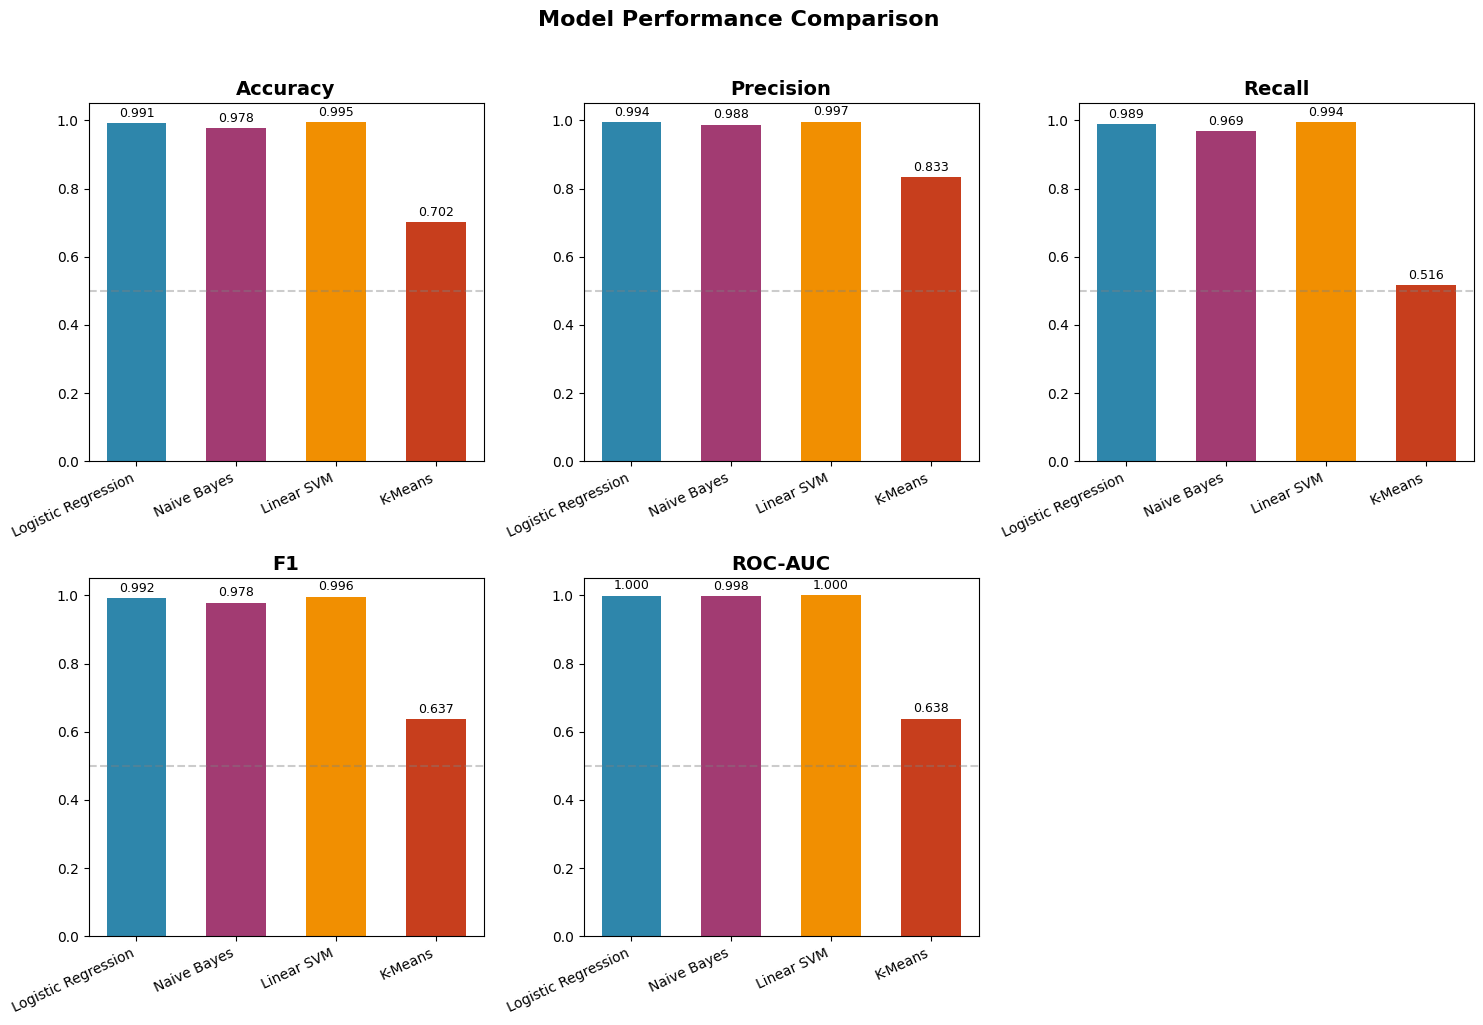

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
model_names = results_df["Model"].tolist()
x = np.arange(len(model_names))

for i, metric in enumerate(metrics_names):
    ax = axes[i]
    values = results_df[metric].values
    bars = ax.bar(x, values, color=colors, width=0.6)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="Random")
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

axes[-1].axis("off")  # Hide unused subplot
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


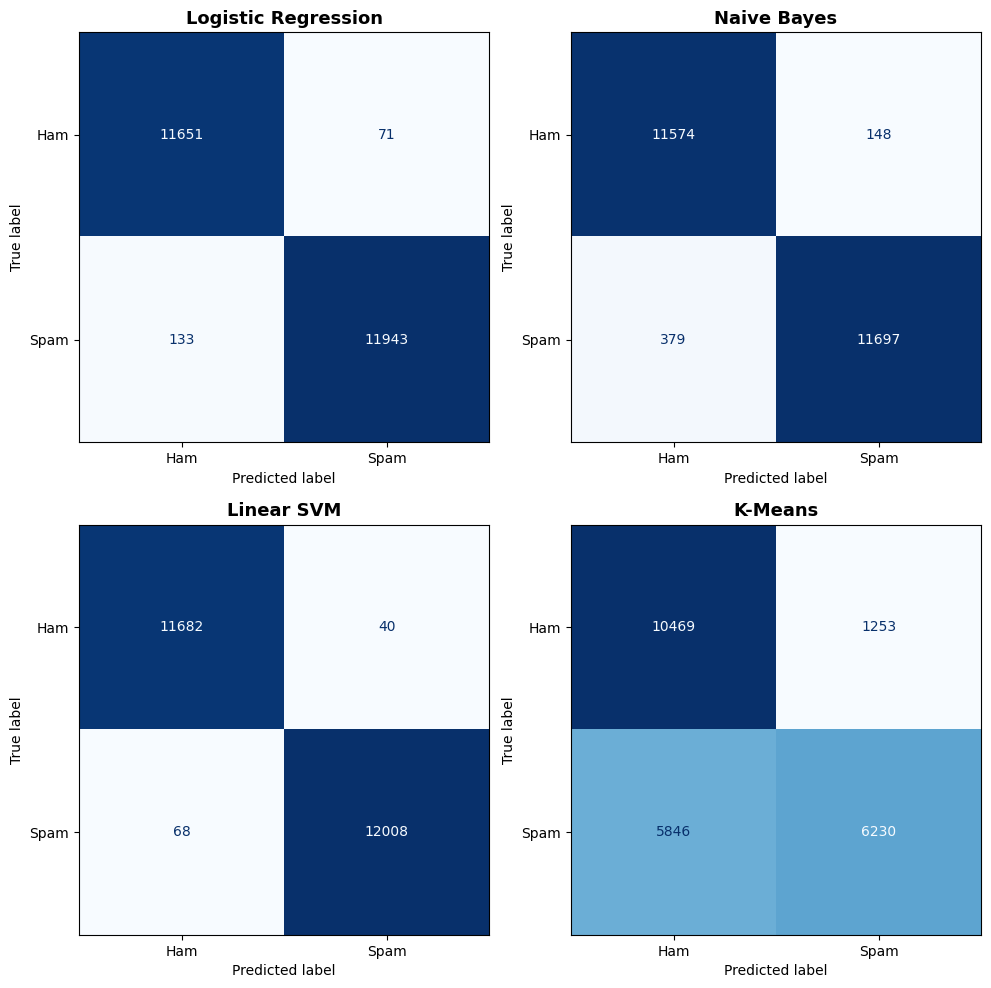

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
model_list = list(conf_matrices.keys())

for i, (name, cm) in enumerate(conf_matrices.items()):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.grid(False)

plt.tight_layout()
plt.show()


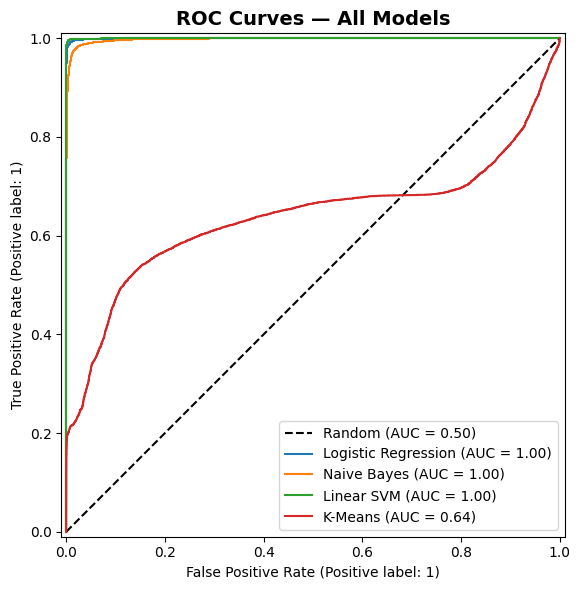

In [9]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")

for name in model_names:
    X_test = X_km_test if name == "K-Means" else X_clf_test
    RocCurveDisplay.from_predictions(
        y_test, scores[name], name=name, ax=ax
    )

ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [10]:
print("=" * 80)
print("              PREDICTIONS ON 11 MODERN TEST EMAILS")
print("=" * 80)

df_test = extract_features(pd.Series(test_emails))
print()

for i, email in enumerate(test_emails):
    print(f"--- Email [{i}] --- {email[:60]}...")
    for name in model_names:
        X_test = df_test[[TEXT_COL] + NUM_COLS] if name != "K-Means" else df_test[TEXT_COL]
        pred = models[name].predict(X_test)[i]

        if name == "K-Means":
            mapped = km_map_1 if pred == 1 else km_map_0
            pred_label = "SPAM" if mapped == 1 else "HAM"
            km_model = models[name]
            tfidf_test = km_model.named_steps["tfidf"].transform(X_test)
            dists = km_model.named_steps["kmeans"].transform(tfidf_test)
            spam_c = 0 if km_map_0 == 1 else 1
            spam_prob = 1 / (1 + np.exp(-np.clip(-dists[i, spam_c], -100, 100)))
            print(f"    {name:25s} {pred_label:5s}  (spam prob: {spam_prob:.2%})")
        elif hasattr(models[name], "predict_proba"):
            prob = models[name].predict_proba(X_test)[i, 1]
            label = "SPAM" if pred == 1 else "HAM"
            print(f"    {name:25s} {label:5s}  (spam prob: {prob:.2%})")
        else:
            score = models[name].decision_function(X_test)[i]
            label = "SPAM" if pred == 1 else "HAM"
            print(f"    {name:25s} {label:5s}  (decision: {score:+.2f})")
    print()

print()
print("Note: All models trained on 2000-era Enron/TREC data.")
print("Modern emails use different spam vocabulary, so predictions may not generalize.")


              PREDICTIONS ON 11 MODERN TEST EMAILS

--- Email [0] --- Congratulations! You won $1000 free cash prize. Click here n...
    Logistic Regression       SPAM   (spam prob: 96.19%)
    Naive Bayes               SPAM   (spam prob: 94.19%)
    Linear SVM                SPAM   (decision: +1.04)
    K-Means                   HAM    (spam prob: 25.73%)

--- Email [1] --- Hi John, please find attached the meeting notes from yesterd...
    Logistic Regression       HAM    (spam prob: 11.08%)
    Naive Bayes               HAM    (spam prob: 0.97%)
    Linear SVM                HAM    (decision: -0.67)
    K-Means                   HAM    (spam prob: 25.75%)

--- Email [2] --- URGENT: Your account has been suspended. Verify now at http:...
    Logistic Regression       SPAM   (spam prob: 98.46%)
    Naive Bayes               SPAM   (spam prob: 86.19%)
    Linear SVM                SPAM   (decision: +1.44)
    K-Means                   HAM    (spam prob: 25.74%)

--- Email [3] --- Can 

In [11]:
print("=" * 80)
print("                          SUMMARY")
print("=" * 80)
print()

# Best model metrics
best_acc = results_df.loc[results_df["Accuracy"].idxmax()]
best_f1 = results_df.loc[results_df["F1"].idxmax()]
best_auc = results_df.loc[results_df["ROC-AUC"].idxmax()]

print(f"Best Accuracy:  {best_acc["Model"]} ({best_acc["Accuracy"]:.4f})")
print(f"Best F1 Score:  {best_f1["Model"]} ({best_f1["F1"]:.4f})")
print(f"Best ROC-AUC:   {best_auc["Model"]} ({best_auc["ROC-AUC"]:.4f})")
print()

# Supervised vs unsupervised gap
sup_models = results_df[results_df["Model"] != "K-Means"]
unsup = results_df[results_df["Model"] == "K-Means"].iloc[0]
print("--- Supervised vs Unsupervised ---")
print(f"Supervised avg accuracy:  {sup_models["Accuracy"].mean():.4f}")
print(f"K-Means accuracy:        {unsup["Accuracy"]:.4f}")
print(f"Gap:                     {sup_models["Accuracy"].mean() - unsup["Accuracy"]:.4f}")
print()

# All three supervised models are close
print("--- Supervised models are near-identical on in-distribution data ---")
print(f"LR:  {sup_models[sup_models["Model"]=="Logistic Regression"]["Accuracy"].values[0]:.4f}")
print(f"NB:  {sup_models[sup_models["Model"]=="Naive Bayes"]["Accuracy"].values[0]:.4f}")
print(f"SVC: {sup_models[sup_models["Model"]=="Linear SVM"]["Accuracy"].values[0]:.4f}")
print()
print("Key takeaway: On this dataset, any linear classifier achieves >97%.")
print("K-Means (unsupervised clustering) cannot compete with supervised methods")
print("for spam classification because it optimizes distance to centroid, not")
print("classification accuracy. The real challenge is generalizing beyond 2000-era data.")


                          SUMMARY

Best Accuracy:  Linear SVM (0.9955)
Best F1 Score:  Linear SVM (0.9955)
Best ROC-AUC:   Linear SVM (0.9999)

--- Supervised vs Unsupervised ---
Supervised avg accuracy:  0.9882
K-Means accuracy:        0.7017
Gap:                     0.2866

--- Supervised models are near-identical on in-distribution data ---
LR:  0.9914
NB:  0.9779
SVC: 0.9955

Key takeaway: On this dataset, any linear classifier achieves >97%.
K-Means (unsupervised clustering) cannot compete with supervised methods
for spam classification because it optimizes distance to centroid, not
classification accuracy. The real challenge is generalizing beyond 2000-era data.
